# Sample 12: virtual strain gauge and strain estimators on an open-hole tension test

**Dataset.** DIC Challenge 1.0, Sample 12: an experimental, painted-speckle carbon-fibre specimen with a
central hole, loaded in tension. **There is no ground truth**, so this notebook compares configurations
against each other; nothing here is an error metric.

**What this establishes for Chapter 5**
1. **VSG study**, after Reu et al.'s Fig. 29: six subset/step/strain-window combinations as principal-strain
   line cuts through the hole, showing the smoothing-versus-noise trade-off.
2. **Strain estimators at matched VSG**: windowed Q4, windowed Q9 and meshfree fits over the *same*
   displacement field and gauge length, split into interior and boundary nodes.

> **Results assume a fresh kernel** (*Restart Kernel → Run All*). Python imports each module once per
> kernel, so re-running cells after editing a file in `validation/` keeps the old code. All correlation
> runs are cached, so a full re-run is quick.

In [1]:
import os
import sys
from pathlib import Path

# The notebook lives in validation/notebooks/; the validation package lives at the repository root.
REPO = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

# Environment variables win, so another machine or a CI job runs the notebook unchanged.
CHALLENGE = Path(os.environ.get("DIC_CHALLENGE", "~/Documents/dicsamples/2D-Challenge1")).expanduser()
RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser()

# True re-runs every configuration even when its output already exists.
FORCE = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from validation.runner import Dataset, SweepPoint, expand_grid, score_run
from validation.workflow import run_point, write_base_config
import tomllib

import cv2

from validation.metrics import virtual_strain_gauge
from validation.truth import NoTruth
from validation.workflow import add_edge_distance, load_frame, run_quality, vertical_cut

print("repo    :", REPO)
print("data    :", CHALLENGE)
print("results :", RESULTS)

## Configuration

- **Only the last frame is correlated.** Correlation is *direct* (`correlation_mode = "spatial"`), so each frame is matched directly to the
  reference and frames are independent; Fig. 29 uses only `oht_cfrp_11`.
- **Search window** is inherited from `Sample12/run.toml` if it sets one, otherwise 81 px. It must exceed
  the largest subset (35 px) plus twice the specimen's motion.
- **Criterion.** Reu used NSSD, which the engine does not provide; ZNSSD is used. NSSD is not zero-mean,
  so it is *not* equivalent to ZNSSD through the ZNCC identity; the criterion therefore differs from Reu's.

In [2]:
SAMPLE_DIR = CHALLENGE / "Sample12"
assert SAMPLE_DIR.is_dir(), f"not found: {SAMPLE_DIR}"

frames = sorted(p.name for p in SAMPLE_DIR.glob("oht_cfrp_*.tif*"))
REFERENCE, LAST = frames[0], frames[-1]
ROI = REPO / "data" / "sample12" / "roi.tiff"
assert ROI.is_file(), f"not found: {ROI}"

SEARCH_SIZE = 81
existing = SAMPLE_DIR / "run.toml"
if existing.exists():
    SEARCH_SIZE = tomllib.loads(existing.read_text()).get("correlation", {}).get("search_size", SEARCH_SIZE)
assert SEARCH_SIZE > 35 and SEARCH_SIZE % 2 == 1, "search_size must be odd and exceed 35"

BASE = {
    "session": {
        "image_dir": str(SAMPLE_DIR),
        "mode": "explicit",
        "reference_frame": REFERENCE,
        "explicit_frame_list": "frames.txt",  # resolved next to the config file
    },
    "setup": {"subset_size": 21, "step_size": 3, "roi_mask": str(ROI)},
    "correlation": {
        "search_size": SEARCH_SIZE,
        "correlation_mode": "spatial",
        "tracking_mode": "eulerian",
        "criterion_name": "znssd",
        "match_threshold": 0.6,
        "n_workers": 4,
        "search": {"method": "brute"},
        "refinement": {"method": "icgn", "shape_function": "affine"},
        "strain": {"method": "lagrange_q4", "strain_window": 5},
        "image_interpolation": {"method": "biquintic_spline"},
    },
}

config_path, runs_root = write_base_config(BASE, "sample12", RESULTS)
(config_path.parent / "frames.txt").write_text(LAST + "\n")
dataset = Dataset("Sample12", config_path, NoTruth("open-hole tension: experimental"))

# Line cut through the specimen centre, which passes through the hole.
roi_mask = cv2.imread(str(ROI), cv2.IMREAD_GRAYSCALE) > 0
X_CUT = float(np.nonzero(roi_mask)[1].mean())
print(f"{len(frames)} frames; correlating {LAST} against {REFERENCE}")
print(f"search window {SEARCH_SIZE} px; line cut at x = {X_CUT:.1f} px")


12 frames; correlating oht_cfrp_11.tiff against oht_cfrp_00.tiff
search window 61 px; line cut at x = 196.1 px


## Study 1: VSG study (cf. Reu et al. Fig. 29)

Reu's six configurations as `(subset, step, strain window)`. The legend gives the VSG, which, rather than the
subset alone, sets the strain spatial resolution: **VSG = (SW − 1)·ST + SS**.

Invalid nodes are kept as NaN, so each curve breaks at the hole instead of bridging it.

In [3]:
REU_FIG29 = [(21, 3, 5), (21, 3, 15), (21, 10, 15), (35, 5, 15), (35, 3, 5), (15, 3, 5)]

vsg_cuts = []
for ss, st, sw in REU_FIG29:
    point = SweepPoint({"setup.subset_size": ss, "setup.step_size": st,
                        "correlation.strain.method": "lagrange_q4",
                        "correlation.strain.strain_window": sw})
    outcome = run_point(dataset, runs_root, point, repo=REPO, force=FORCE)
    if not outcome.ok:
        continue
    frame = load_frame(outcome.output_dir)
    vsg_cuts.append(vertical_cut(frame, X_CUT).assign(
        subset=ss, step=st, window=sw,
        vsg_px=virtual_strain_gauge(ss, st, strain_window=sw),
        **run_quality(outcome.output_dir)))
vsg_cuts = pd.concat(vsg_cuts, ignore_index=True)

vsg_cuts.groupby(["subset", "step", "window"], sort=False).agg(
    vsg_px=("vsg_px", "first"), roi_nodes=("roi_nodes", "first"),
    valid_rate_roi=("valid_rate_roi", "first"), nonconverged_pct=("nonconverged_pct", "first"),
    points=("e1", "count"))

  ed2042ec72  reused  


  7d26a53055  reused  


  82fcb1d0da  reused  
  e9d7682401  reused  
  31734b0497  reused  


  1d76d2baba  reused  


vsg_px  roi_nodes  valid_rate_roi  nonconverged_pct  \
subset step window                                                        
21     3    5         33.0      32240        0.957010               0.0   
            15        63.0      32240        0.957010               0.0   
       10   15       161.0       2932        0.959072               0.0   
35     5    15       105.0      10800        0.973611               0.0   
       3    5         47.0      29993        0.971493               0.0   
15     3    5         27.0      33282        0.951445               0.0   

                    points  
subset step window          
21     3    5          285  
            15         285  
       10   15          85  
35     5    15         169  
       3    5          280  
15     3    5          287

**Check the valid rate first.** It is computed over the nodes inside the ROI, so grid points that fall in
the hole or outside the specimen do not count as failures. A low value on the large-subset runs would mean
the search window is too small for the specimen's motion, not that the configuration is poor.
`nonconverged_pct` is the share of valid nodes whose IC-GN iteration stopped without reaching its
tolerance; the engine keeps them if their score passes the threshold.

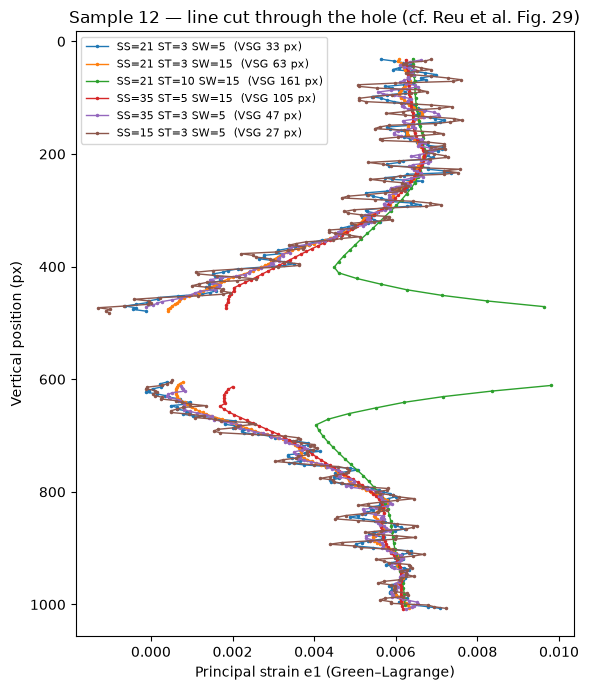

In [4]:
fig, ax = plt.subplots(figsize=(6, 7))
for (ss, st, sw), g in vsg_cuts.groupby(["subset", "step", "window"], sort=False):
    ax.plot(g.e1, g.y0, marker=".", ms=3, lw=1,
            label=f"SS={ss} ST={st} SW={sw}  (VSG {g.vsg_px.iloc[0]:.0f} px)")
ax.invert_yaxis()  # image coordinates: y increases downward
ax.set_xlabel("Principal strain e1 (Green–Lagrange)")
ax.set_ylabel("Vertical position (px)")
ax.set_title("Sample 12 — line cut through the hole (cf. Reu et al. Fig. 29)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "sample12_linecut.pdf", dpi=300)

**The large-VSG spike at the hole edge.** At a node next to the hole, part of a large strain window lies
in invalid territory. The redundancy check counts the remaining points, finds enough, and fits a polynomial
evaluated at the *edge* of its own data: an extrapolation across a steep gradient, which overshoots. It is
a property of one-sided windows, quantified below; it is not fixed here.

## Study 2: strain estimators at matched VSG

Same subset, step and displacement field; only the estimator changes. For a windowed fit
VSG = (SW − 1)·ST + SS; for the meshfree fit VSG = 2r + SS, so the matching radius is
**r = (SW − 1)·ST / 2**.

| estimator | fit | parameters |
|---|---|---|
| Q4 | 1, m, n, mn | 4 |
| Q9 | Q4 + m², n², m²n, mn², m²n² | 9 |
| meshfree | 1, Δx, Δy | 3 |

Differences therefore combine neighbourhood shape (square vs disc) and fit order.

In [5]:
SUBSET, STEP = 21, 3
WINDOWS = [5, 15]

def estimator_points(sw: int) -> dict[str, SweepPoint]:
    common = {"setup.subset_size": SUBSET, "setup.step_size": STEP}
    return {
        "Q4": SweepPoint({**common, "correlation.strain.method": "lagrange_q4",
                          "correlation.strain.strain_window": sw}),
        "Q9": SweepPoint({**common, "correlation.strain.method": "lagrange_q9",
                          "correlation.strain.strain_window": sw}),
        "meshfree": SweepPoint({**common, "correlation.strain.method": "lagrange_cloud",
                                "correlation.strain.radius_px": (sw - 1) * STEP / 2.0}),
    }

est_cuts = []
for sw in WINDOWS:
    vsg = virtual_strain_gauge(SUBSET, STEP, strain_window=sw)
    for name, point in estimator_points(sw).items():
        outcome = run_point(dataset, runs_root, point, repo=REPO, force=FORCE)
        if not outcome.ok:
            continue
        frame = add_edge_distance(load_frame(outcome.output_dir))
        est_cuts.append(vertical_cut(frame, X_CUT).assign(estimator=name, window=sw, vsg_px=vsg))
est_cuts = pd.concat(est_cuts, ignore_index=True)

# Interior: the square window (and the matched disc inside it) never touches an invalid
# node or the grid edge, so the fit is two-sided. Boundary: it does, so it is one-sided.
est_cuts["region"] = np.where(est_cuts.edge_nodes > (est_cuts.window - 1) // 2, "interior", "boundary")


  ed2042ec72  reused  
  a8327690f0  reused  


  f2c54b469f  reused  
  7d26a53055  reused  


  f80e21c769  reused  
  094e72920c  reused  


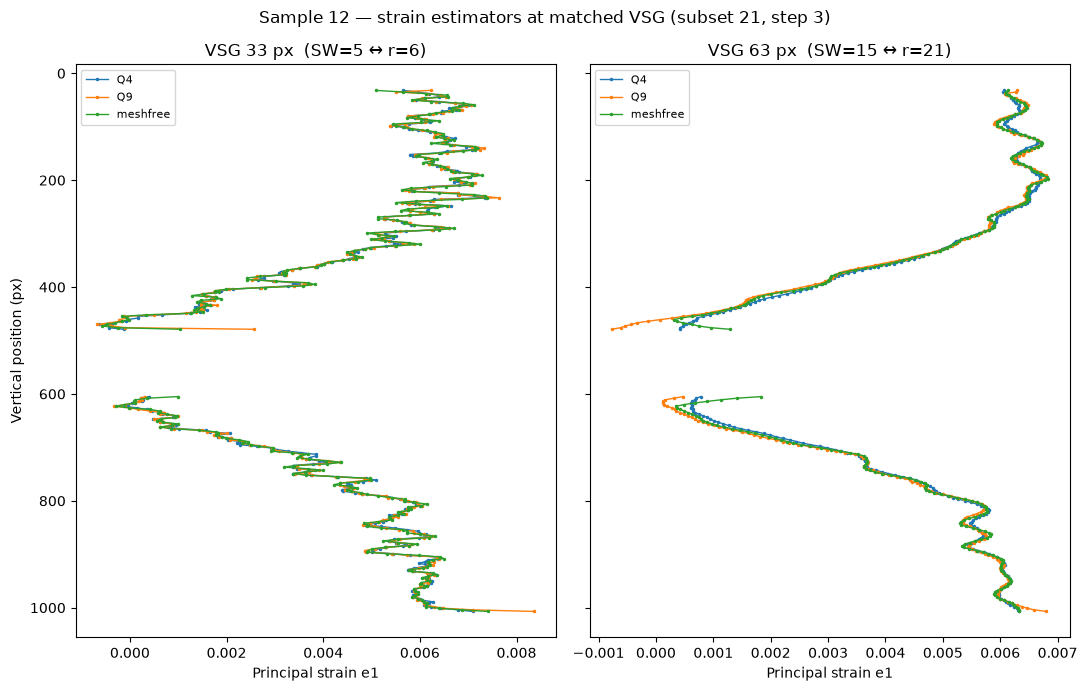

In [6]:
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(11, 7), sharey=True)
for ax, sw in zip(np.atleast_1d(axes), WINDOWS):
    sub = est_cuts[est_cuts.window == sw]
    for name, g in sub.groupby("estimator"):
        ax.plot(g.e1, g.y0, marker=".", ms=3, lw=1, label=name)
    ax.set_title(f"VSG {sub.vsg_px.iloc[0]:.0f} px  (SW={sw} ↔ r={(sw - 1) * STEP / 2:g})")
    ax.set_xlabel("Principal strain e1")
    ax.legend(fontsize=8)
axes[0].invert_yaxis()
axes[0].set_ylabel("Vertical position (px)")
fig.suptitle(f"Sample 12 — strain estimators at matched VSG (subset {SUBSET}, step {STEP})")
fig.tight_layout()
fig.savefig(RESULTS / "sample12_linecut_reu29.pdf", dpi=300)


## Estimator disagreement, interior vs boundary

The displacement field is identical across the three runs, so node-by-node differences measure what the
estimator choice alone does to the reported strain. The node counts are given beside the statistics:
the boundary band is thin, especially at SW = 5.

In [7]:
def max_abs(s):
    return s.abs().max()

wide = est_cuts.pivot_table(index=["window", "region", "y0"], columns="estimator", values="e1").dropna()
diff = pd.DataFrame({"Q9 - Q4": wide["Q9"] - wide["Q4"],
                     "meshfree - Q4": wide["meshfree"] - wide["Q4"]})
estimator_table = diff.groupby(level=["window", "region"]).agg(["mean", "std", max_abs])
estimator_table.insert(0, "nodes", wide.groupby(level=["window", "region"]).size())
estimator_table.round(6)


nodes   Q9 - Q4                     meshfree - Q4            \
                           mean       std   max_abs          mean       std   
window region                                                                 
5      boundary     8  0.000581  0.000994  0.002690      0.000198  0.000532   
       interior   277 -0.000009  0.000108  0.000356     -0.000006  0.000162   
15     boundary    28 -0.000277  0.000472  0.001188      0.000129  0.000329   
       interior   257 -0.000075  0.000116  0.000429     -0.000043  0.000087   

                           
                  max_abs  
window region              
5      boundary  0.001169  
       interior  0.000580  
15     boundary  0.001052  
       interior  0.000281

**Reading it.** Interior disagreement at noise level with near-zero mean means the estimator has little effect
where the fit is two-sided. Boundary scatter several times larger, with Q9 worst, means it matters at free
edges, where the highest-order polynomial extrapolates worst from a one-sided neighbourhood. A small interior mean offset at the larger window is a fit-order effect: Q9's $mn^2$ and $m^2n$ terms
are not orthogonal to the linear terms on a square window, so Q9 reports the gradient at the node while Q4
reports a window average. The node count alone does not make the offset statistically significant:
neighbouring nodes on the cut are a few pixels apart but average over the whole gauge length, so their
differences are strongly correlated and the effective number of independent samples is roughly the cut
length divided by the VSG, not the number of nodes.

In [8]:
out = RESULTS / "sample12"
out.mkdir(parents=True, exist_ok=True)
vsg_cuts.to_csv(out / "sample12_vsg_linecuts.csv", index=False)
est_cuts.to_csv(out / "sample12_estimator_linecuts.csv", index=False)
estimator_table.to_csv(out / "sample12_estimator_table.csv")
for f in ("sample12_vsg_linecuts.csv", "sample12_estimator_linecuts.csv", "sample12_estimator_table.csv"):
    print("wrote", out / f)


## Figures for the thesis

Full-field maps from the runs above (all cached, so nothing is correlated again). Nodes that failed, the
hole and everything outside the ROI are left blank. The colour scales follow the results preview:
each map is bounded by its 1st and 99th percentiles, the scale spans all maps of a figure, and values
beyond it are clipped (marked by the colour-bar ends).

**Major principal strain for the six gauges of the VSG study.** Q4 estimator, one shared colour scale; the
thin line is the x = 196 px cut of the line-cut figures.

  ed2042ec72  reused  
  7d26a53055  reused  


  82fcb1d0da  reused  
  e9d7682401  reused  
  31734b0497  reused  
  1d76d2baba  reused  


shared e1 scale: 0.00143 to 0.01354 (clipped: both)


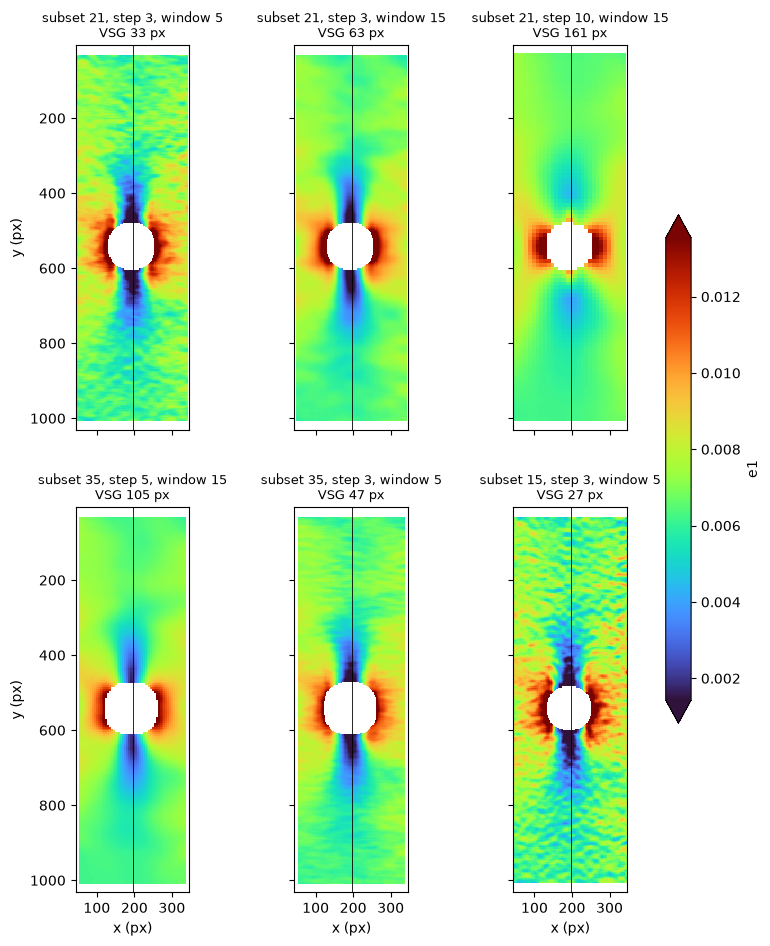

In [9]:
from scipy import ndimage

from icorrvision.results.payload import DIVERGING_CMAP, SCALE_PERCENTILES, STRAIN_CMAP


def cached_frame(point: SweepPoint) -> pd.DataFrame:
    outcome = run_point(dataset, runs_root, point, repo=REPO, force=False)
    assert outcome.ok and outcome.skipped, "expected a cached run; stopping rather than correlating"
    return load_frame(outcome.output_dir)


def to_grid(frame: pd.DataFrame, values: pd.Series) -> tuple[np.ndarray, list[float]]:
    """Node values on the (row, col) grid, NaN where invalid, with the imshow extent in px."""
    grid = np.full((frame.row_index.max() + 1, frame.col_index.max() + 1), np.nan)
    grid[frame.row_index, frame.col_index] = np.where(frame.valid, values, np.nan)
    half = (frame.x0.max() - frame.x0.min()) / max(frame.col_index.max(), 1) / 2
    extent = [frame.x0.min() - half, frame.x0.max() + half, frame.y0.max() + half, frame.y0.min() - half]
    return grid, extent


def shared_scale(grids: list[np.ndarray]) -> tuple[float, float, str]:
    """The preview's rule over several maps: widest 1st-99th percentile range, clipped ends marked."""
    samples = [g[np.isfinite(g)] for g in grids]
    lo = min(np.percentile(s, SCALE_PERCENTILES[0]) for s in samples)
    hi = max(np.percentile(s, SCALE_PERCENTILES[1]) for s in samples)
    below = any(s.min() < lo for s in samples)
    above = any(s.max() > hi for s in samples)
    return lo, hi, {(True, True): "both", (True, False): "min", (False, True): "max"}.get((below, above), "neither")


e1_maps = []
for ss, st, sw in REU_FIG29:
    frame = cached_frame(SweepPoint({"setup.subset_size": ss, "setup.step_size": st,
                                     "correlation.strain.method": "lagrange_q4",
                                     "correlation.strain.strain_window": sw}))
    e1_maps.append(((ss, st, sw), *to_grid(frame, frame.e1)))

lo, hi, extend = shared_scale([g for _, g, _ in e1_maps])
fig, axes = plt.subplots(2, 3, figsize=(10, 11), sharex=True, sharey=True)
for ax, ((ss, st, sw), grid, extent) in zip(axes.flat, e1_maps):
    image = ax.imshow(grid, extent=extent, cmap=STRAIN_CMAP, vmin=lo, vmax=hi, interpolation="nearest")
    ax.axvline(X_CUT, color="k", lw=0.6)
    ax.set_title(f"subset {ss}, step {st}, window {sw}\nVSG {virtual_strain_gauge(ss, st, strain_window=sw):g} px",
                 fontsize=9)
    ax.set_aspect("equal")
for ax in axes[-1]:
    ax.set_xlabel("x (px)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (px)")
fig.colorbar(image, ax=axes, shrink=0.6, extend=extend, label="e1")
fig.savefig(RESULTS / "sample12_e1_maps.pdf", dpi=300)
print(f"shared e1 scale: {lo:.5f} to {hi:.5f} (clipped: {extend})")


**Estimator differences at matched gauges.** Q9 − Q4 and meshfree − Q4 at the two matched VSGs of Study 2
(window 5 → 33 px, window 15 → 63 px), in µε, on one symmetric diverging scale shared by the four panels.
All three estimators share the displacement grid of each run, so differences are taken node by node. The
table locates each map's largest absolute difference relative to the hole and to the outer ROI edge.

  ed2042ec72  reused  
  a8327690f0  reused  


  f2c54b469f  reused  
  7d26a53055  reused  


  f80e21c769  reused  
  094e72920c  reused  


shared difference scale: ±943 µε (clipped: both)


,map,VSG (px),max |diff| (µε),x (px),y (px),to hole edge (px),to outer ROI edge (px)
0,Q9 - Q4,33.0,7109.8,132.0,518.0,13.6,95.0
1,meshfree - Q4,33.0,2572.8,129.0,557.0,13.9,92.0
2,Q9 - Q4,63.0,2914.5,138.0,506.0,13.9,101.0
3,meshfree - Q4,63.0,2611.0,252.0,518.0,13.4,103.0


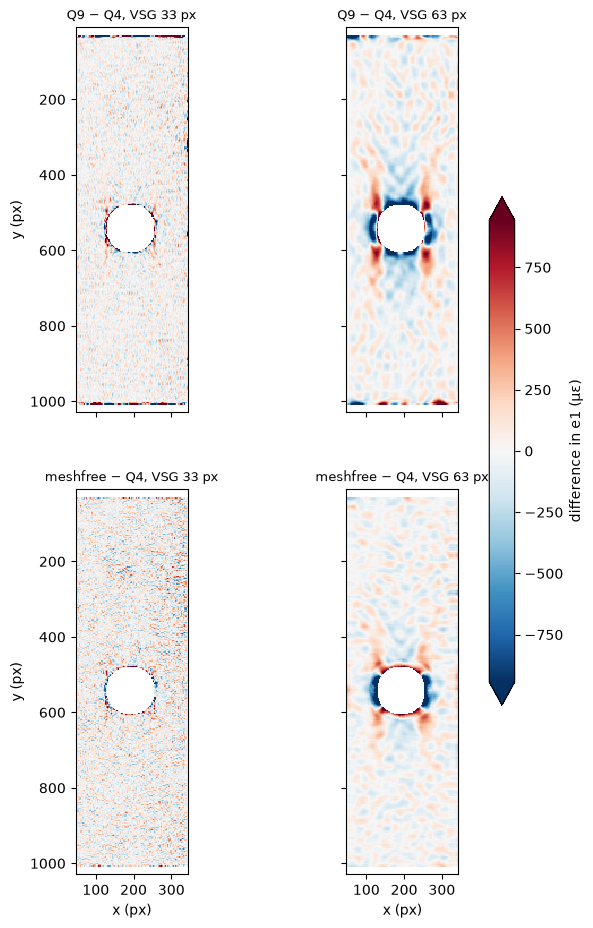

In [10]:
# The hole is the part of the specimen outside the ROI that does not touch the image border.
labels, count = ndimage.label(~roi_mask)
border = set(np.unique(np.concatenate([labels[0], labels[-1], labels[:, 0], labels[:, -1]])))
hole = np.isin(labels, [k for k in range(1, count + 1) if k not in border])
hole_edge = ndimage.distance_transform_edt(~hole)      # px from each pixel to the hole
outer = ndimage.binary_fill_holes(roi_mask)
outer_edge = ndimage.distance_transform_edt(outer)     # px from each pixel to the outer ROI boundary

diff_maps, located = [], []
for sw in WINDOWS:
    vsg = virtual_strain_gauge(SUBSET, STEP, strain_window=sw)
    frames = {name: cached_frame(point).set_index(["row_index", "col_index"])
              for name, point in estimator_points(sw).items()}
    q4 = frames["Q4"]
    for name in ("Q9", "meshfree"):
        other = frames[name]
        both = q4.valid & other.valid
        d = q4.assign(valid=both, diff=(other.e1 - q4.e1) * 1e6).reset_index()
        grid, extent = to_grid(d, d["diff"])
        diff_maps.append((f"{name} − Q4, VSG {vsg:g} px", grid, extent))
        worst = d[d.valid].loc[lambda t: t["diff"].abs().idxmax()]
        xi, yi = int(round(worst.x0)), int(round(worst.y0))
        located.append({"map": f"{name} - Q4", "VSG (px)": vsg, "max |diff| (µε)": abs(worst["diff"]),
                        "x (px)": worst.x0, "y (px)": worst.y0,
                        "to hole edge (px)": hole_edge[yi, xi], "to outer ROI edge (px)": outer_edge[yi, xi]})

samples = [g[np.isfinite(g)] for _, g, _ in diff_maps]
half = max(max(abs(np.percentile(s, SCALE_PERCENTILES[0])), abs(np.percentile(s, SCALE_PERCENTILES[1])))
           for s in samples)
extend = "both" if any(np.abs(s).max() > half for s in samples) else "neither"
fig, axes = plt.subplots(2, 2, figsize=(8, 11), sharex=True, sharey=True)
for ax, (title, grid, extent) in zip(axes.T.flat, diff_maps):
    image = ax.imshow(grid, extent=extent, cmap=DIVERGING_CMAP, vmin=-half, vmax=half, interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
for ax in axes[-1]:
    ax.set_xlabel("x (px)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (px)")
fig.colorbar(image, ax=axes, shrink=0.6, extend=extend, label="difference in e1 (µε)")
fig.savefig(RESULTS / "sample12_estimator_diff_maps.pdf", dpi=300)
print(f"shared difference scale: ±{half:.0f} µε (clipped: {extend})")
pd.DataFrame(located).round(1)
